In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('house.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<p>As garage col has almost 5% missing val, it will be ideal to perform imputation on it and not so much for fireplace column.</p>

<h1>Using Pandas</h1>

In [5]:
#mode imputation GarageQual
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

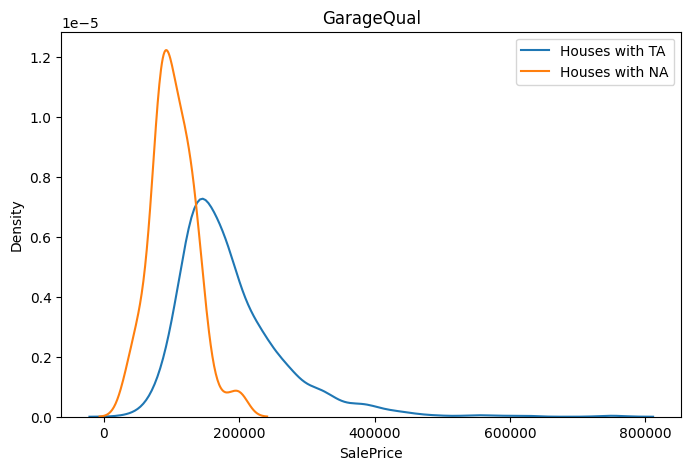

In [12]:
plt.figure(figsize=(8,5))

sns.kdeplot(df[df['GarageQual']=='TA']['SalePrice'],label='Houses with TA')
sns.kdeplot(df[df['GarageQual'].isnull()]['SalePrice'],label='Houses with NA')

plt.legend()
plt.title('GarageQual')

In [13]:
original=df[df['GarageQual']=='TA']['SalePrice']

In [14]:
df['GarageQual'].fillna('TA',inplace=True)

C:\Users\souha\AppData\Local\Temp\ipykernel_12692\584385255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA',inplace=True)


Text(0.5, 1.0, 'GarageQual')

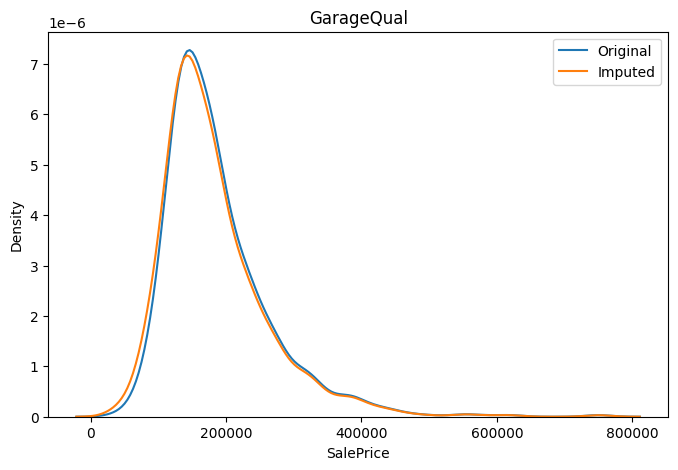

In [17]:
plt.figure(figsize=(8,5))

sns.kdeplot(original,label='Original')
sns.kdeplot(df[df['GarageQual']=='TA']['SalePrice'],label='Imputed')

plt.legend()
plt.title('GarageQual')

<p>After Imputation the distribution didnt change so we can say that it worked nicely.</p>

In [19]:
#mode imputation FireplaceQu
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

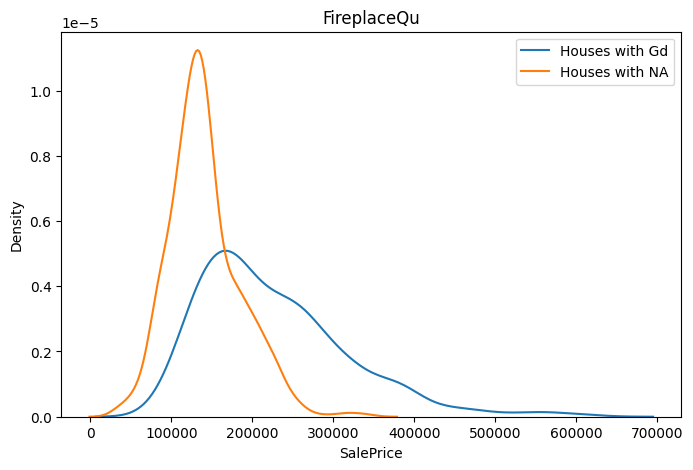

In [21]:
plt.figure(figsize=(8,5))

sns.kdeplot(df[df['FireplaceQu']=='Gd']['SalePrice'],label='Houses with Gd')
sns.kdeplot(df[df['FireplaceQu'].isnull()]['SalePrice'],label='Houses with NA')

plt.legend()
plt.title('FireplaceQu')

In [22]:
original_fire=df[df['FireplaceQu']=='Gd']['SalePrice']

In [23]:
df['FireplaceQu'].fillna('Gd',inplace=True)

C:\Users\souha\AppData\Local\Temp\ipykernel_12692\891419280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd',inplace=True)


Text(0.5, 1.0, 'FireplaceQu')

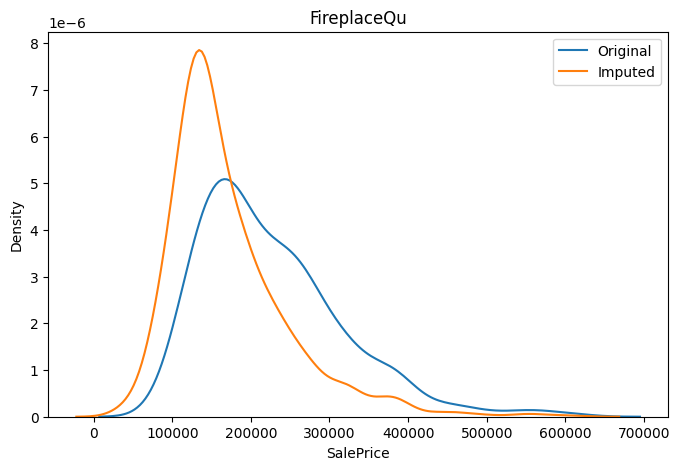

In [24]:
plt.figure(figsize=(8,5))

sns.kdeplot(original_fire,label='Original')
sns.kdeplot(df[df['FireplaceQu']=='Gd']['SalePrice'],label='Imputed')

plt.legend()
plt.title('FireplaceQu')

<p>Too much difference in PDF, so for this col this imputation is not appropiate.</p>

<h1>Using Sklearn</h1>

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(['SalePrice'],axis=1),
                                               df['SalePrice'],
                                               test_size=0.2)

In [26]:
from sklearn.impute import SimpleImputer

In [27]:
imputer=SimpleImputer(strategy='most_frequent')

In [28]:
x_train_imp=imputer.fit_transform(x_train)
x_test_imp=imputer.transform(x_test)

In [29]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)